# *Set A* - **Predict campaign responses and identify audience segments.**

In [1]:
from pathlib import Path

import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import joblib, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, silhouette_score)

os.makedirs("MIP-1/outputs/figures", exist_ok=True)
os.makedirs("MIP-1/models", exist_ok=True)

In [2]:
# Data genrations

rng = np.random.default_rng(404)
n = 300
cols = ['visits', 'recency', 'engagement', 'spend']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, -0.9, 1.1, 0.4])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["response"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("MIP-1/data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("MIP-1/data/raw/set_d.csv", index=False)


### Task 1 - Maths & Adv Stats

In [46]:
raw = pd.read_csv("MIP-1/data/raw/set_d.csv")
display(raw.head())


,record_id,visits,recency,engagement,spend,group,response
0,1,53.96,43.84,54.57,58.93,G2,1
1,2,NaN,49.75,52.97,63.64,G2,1
2,3,35.39,66.52,44.98,47.33,G2,0
3,4,45.01,42.80,47.62,54.48,G1,1
4,5,53.84,53.72,48.33,58.30,G2,1


In [47]:
df = raw.drop_duplicates().reset_index(drop=True)

train_val, test = train_test_split(df, test_size=0.2, stratify=df.response, random_state=42)
fit, val = train_test_split(train_val, test_size=0.2, stratify=train_val.response, random_state=42)
print(len(fit), len(val), len(test))

192 48 60


{'n': 192, 'mean': np.float64(51.0), 'median': 51.405, 'std_ddof1': 10.29}


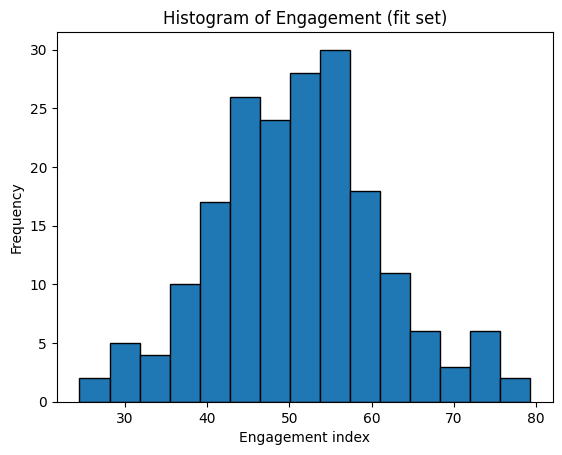

In [94]:
e = fit["engagement"].dropna()

summary = {"n": len(e),
           "mean": round(e.mean(),2),
           "median": e.median(),
           "std_ddof1": round(e.std(ddof=1),2)}

print(summary)

plt.hist(e, bins=15, edgecolor="black")
plt.title("Histogram of Engagement (fit set)")
plt.xlabel("Engagement index")
plt.ylabel("Frequency")
plt.savefig("MIP-1/outputs/figures/engagement_hist.png")
plt.show()


In [88]:
# H0: mean engagement G1 = G2
# H1: mean engagement G1 != G2 (two-sided, alpha = 0.05)
g1 = fit[fit.group == "G1"]["engagement"].dropna()
g2 = fit[fit.group == "G2"]["engagement"].dropna()
t, p = stats.ttest_ind(g1, g2, equal_var=False)
print("n G1:", len(g1), "| n G2:", len(g2), "| t:", t.round(2), "| p:", p.round(2))

ci = stats.t.interval(0.95, df=len(e)-1, loc=e.mean(), scale=stats.sem(e))
print("95% CI:",np.array(ci).round(2))

n G1: 84 | n G2: 108 | t: 0.72 | p: 0.47
95% CI: [49.54 52.47]


In [89]:
X = fit[["engagement", "visits"]].dropna().values
Xc = X - X.mean(axis=0)
cov = Xc.T @ Xc / (len(X) - 1)
print("n:", len(X), "\nCovariance:\n", cov.round(2))

vals, vecs = np.linalg.eigh(cov)
print("\nEigenvalues:", vals.round(2))
print("Largest / sum:", round(vals.max() / vals.sum(), 2))
print("Principal direction:", vecs[:, -1].round(2))

n: 181 
Covariance:
 [[103.66   4.12]
 [  4.12 103.06]]

Eigenvalues: [ 99.23 107.49]
Largest / sum: 0.52
Principal direction: [-0.73 -0.68]


### Task 2 - Data Preprocessing & Feature Engineering

In [51]:
print(f'Dataset shape: {raw.shape}')
print(f'\nData type: \n{raw.dtypes}')
print(f'\nMissing values: \n{raw.isna().sum()}')
print(f'\nDuplicate rows: {raw.duplicated().sum()}')

Dataset shape: (305, 7)

Data type: 
record_id       int64
visits        float64
recency       float64
engagement    float64
spend         float64
group          object
response        int64
dtype: object

Missing values: 
record_id      0
visits        16
recency       15
engagement     0
spend          0
group          0
response       0
dtype: int64

Duplicate rows: 5


In [58]:
num = ['visits', 'recency', 'engagement', 'spend']

imp = SimpleImputer(strategy="median").fit(fit[num])
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(fit[["group"]])

def impute_and_engineer(d):
    X = pd.DataFrame(imp.transform(d[num]), columns=num, index=d.index)
    X["engineered_feature"] = X["engagement"] / (X["recency"] + 1)
    return X

num_cols = num + ["engineered_feature"]
scaler = StandardScaler().fit(impute_and_engineer(fit)[num_cols])

def transform(d):
    return np.hstack([scaler.transform(impute_and_engineer(d)[num_cols]),
                      ohe.transform(d[["group"]])])

Xf, Xv, Xt = transform(fit), transform(val), transform(test)
yf, yv, yt = fit.response.values, val.response.values, test.response.values

feature_names = num_cols + list(ohe.get_feature_names_out(["group"]))
print(Xf.shape, Xv.shape, Xt.shape)
print(feature_names)

joblib.dump({"imputer": imp, "ohe": ohe, "scaler": scaler}, "models/preprocessing.joblib")

(192, 7) (48, 7) (60, 7)
['visits', 'recency', 'engagement', 'spend', 'engineered_feature', 'group_G1', 'group_G2']


['models/preprocessing.joblib']

### Task 3 - *Supervised Learning*

In [95]:
dummy = DummyClassifier(strategy="most_frequent").fit(Xf, yf)
lr = LogisticRegression(max_iter=1000).fit(Xf, yf)

def evaluate(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)}

lr_pred = (lr.predict_proba(Xt)[:, 1] >= 0.5).astype(int)
results = {"baseline": evaluate(yt, dummy.predict(Xt)), "logistic": evaluate(yt, lr_pred)}
print(pd.DataFrame(results).T.round(2))


          accuracy  precision  recall    f1
baseline      0.58       0.58    1.00  0.74
logistic      0.82       0.83    0.86  0.85


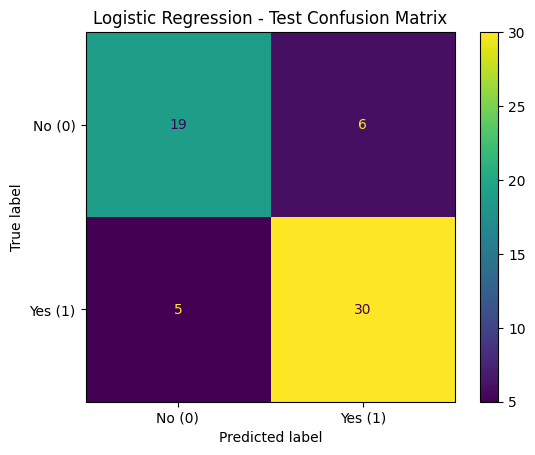

In [72]:
ConfusionMatrixDisplay(confusion_matrix(yt, lr_pred), display_labels=["No (0)", "Yes (1)"]).plot()
plt.title("Logistic Regression - Test Confusion Matrix")
plt.savefig("MIP-1/outputs/figures/cm_logistic.png")
plt.show()

### Task 4 - *Unsupervised Learning*

---



In [99]:
Xc_num = Xf[:, :5]   # scaled numeric + engineered_feature only

rows = []
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xc_num)
    rows.append((k, km.inertia_, silhouette_score(Xc_num, km.labels_)))
scores = pd.DataFrame(rows, columns=["k", "inertia", "silhouette"])
display(scores.round(2))

best_k = int(scores.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
print("\nChosen k:", best_k)


,k,inertia,silhouette
0,2,713.03,0.23
1,3,613.55,0.19
2,4,541.65,0.19



Chosen k: 2


In [70]:

km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xc_num)
prof = impute_and_engineer(fit)[num_cols].copy()
prof["cluster"] = km.labels_
display(prof.groupby("cluster").mean().round(2).assign(size=prof.groupby("cluster").size()))

,visits,recency,engagement,spend,engineered_feature,size
cluster,,,,,,
0,49.37,55.25,46.09,50.18,0.83,109
1,49.54,44.17,57.45,50.97,1.29,83


### Task 5 - *Deep Learing up to ANN*

In [64]:
tf.keras.utils.set_random_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(Xf.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")])
model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="binary_crossentropy")
model.summary()

es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
hist = model.fit(Xf, yf, validation_data=(Xv, yv), epochs=50, batch_size=16,
                 callbacks=[es], verbose=0)
print("Epochs run:", len(hist.history["loss"]), "| Seed: 42")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

Epochs run: 50 | Seed: 42


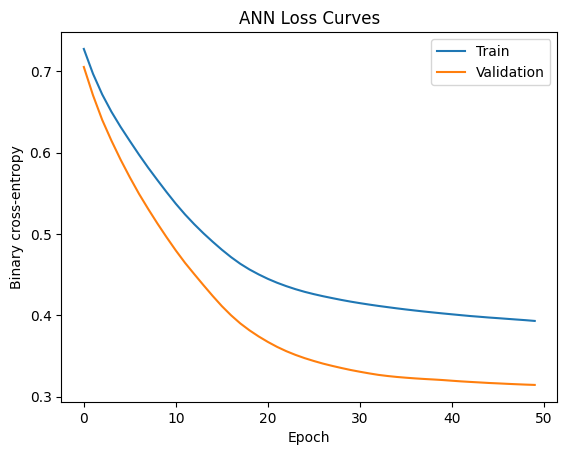

In [65]:
plt.plot(hist.history["loss"], label="Train")
plt.plot(hist.history["val_loss"], label="Validation")
plt.title("ANN Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.legend()
plt.savefig("MIP-1/outputs/figures/ann_loss.png")
plt.show()


In [101]:

ann_pred = (model.predict(Xt, verbose=0).ravel() >= 0.5).astype(int)
results["ann"] = evaluate(yt, ann_pred)
print(pd.DataFrame(results).T.round(2))


          accuracy  precision  recall    f1
baseline      0.58       0.58    1.00  0.74
logistic      0.82       0.83    0.86  0.85
ann           0.83       0.84    0.89  0.86


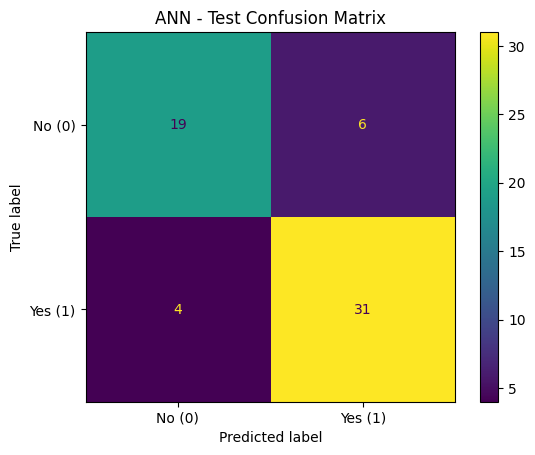

In [67]:
ConfusionMatrixDisplay(confusion_matrix(yt, ann_pred), display_labels=["No (0)", "Yes (1)"]).plot()
plt.title("ANN - Test Confusion Matrix")
plt.savefig("MIP-1/outputs/figures/cm_ann.png")
plt.show()

model.save("models/ann.keras")